In [105]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

In [106]:
AAPL = yf.download('BTC-USD', start='2020-01-01', end='2025-01-01')['Close'] # ^GSPC
dataset = AAPL.values # get the close price. 
scaler = MinMaxScaler(feature_range=(0,1)) # scaling input and output
dates = AAPL.filter(['Close'])
scaled_data = np.array(scaler.fit_transform(dataset))
data = [i[0] for i in scaled_data]
min_value, max_value = min(dataset), max(dataset)
print(len(data))

C:\Users\Phi Hung Nguyen\AppData\Local\Temp\ipykernel_4492\923235655.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  AAPL = yf.download('BTC-USD', start='2020-01-01', end='2025-01-01')['Close'] # ^GSPC
[*********************100%***********************]  1 of 1 completed

1827


We analyze whether collecting two quadratures and one quadrature assissting in performance.
- When no mask is applied
- When masked is applied

In [108]:
df = pd.read_csv("BTC_features_10rep_phipithird.csv")
X_p = extract_delayed_p_or_q_single_column(df,column_name="PQ-15",N=10,repeat_steps=10)
X_p.shape

(1827, 10)

In [109]:
df = pd.read_csv("BTC_features_10rep_phipithird.csv")
column_names = [f"PQ-{i}" for i in range(15, 0, -1)] + ["PQ0"]
X_p_row = extract_p_row(df,column_names=column_names,repeat_steps=10,keep_last=True)
X_p_row.shape

(1827, 16)

In [110]:
df = pd.read_csv("BTC_features_10rep_phipithird.csv")
X_pq = extract_delayed_single_column(df,column_name="PQ0",N=10,repeat_steps=10)
X_pq.shape

(1827, 10)

In [111]:
X_p = add_polynomial_features(X_p,nodes=10)
X_pq = add_polynomial_features(X_pq,nodes=10)
X_p_row = add_polynomial_features(X_p_row,nodes=10)

We perform rollover test with standard deviation

In [136]:
def rollover(start, end, name, X_features, tau=1, Nfading=10):
    prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
    dataset = prices.values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset).flatten()
    M_test = end - start - 2
    results = []
    errors = []
    for test_round in range(M_test):
        train_start = start + test_round
        train_end = train_start + 2
        test_end = train_start + 3
        stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
        stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]

        Ntotal = len(stock_3yr)
        Ntraining = len(stock_2yr) - Nfading
        Ntesting = Ntotal - Nfading - Ntraining
        K = Ntotal - tau

        # index position in the full 2020-2025 dataset
        window_start_date = stock_3yr.index[0]
        index = prices.index.get_loc(window_start_date)
        X = X_features[index : index + K, :]
        X_train = X[Nfading : Nfading + Ntraining, :]
        X_test = X[Nfading + Ntraining : Nfading + Ntraining + Ntesting, :]

        y_target = scaled_data[index + tau : index + K + tau]
        y_train = y_target[Nfading : Nfading + Ntraining]
        y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]

        W = fitting_function(X_train, y_train)
        y_prediction = predict(X_test, W)

        error = nrmse(y_prediction, y_test)
        errors.append(error)
        print(f"Round {test_round}")
        print(f"Train: {train_start}-01-01 to {train_end}-01-01")
        print(f"Test:  {train_end}-01-01 to {test_end}-01-01")
        print("Ntotal:", Ntotal)
        print("Ntraining:", Ntraining)
        print("Ntesting:", Ntesting)
        print("X_train shape:", X_train.shape)
        print("X_test shape:", X_test.shape)
        print("y_train shape:", y_train.shape)
        print("y_test shape:", y_test.shape)
        print("NRMSE:", error)
        print("-" * 40)

        results.append({
            "round": test_round,
            "train_start": train_start,
            "train_end": train_end,
            "test_start": train_end,
            "test_end": test_end,
            "Ntotal": Ntotal,
            "Ntraining": Ntraining,
            "Ntesting": Ntesting,
            "NRMSE": error,
        })

    errors = np.array(errors)

    mean_error = np.mean(errors)
    std_error = np.std(errors, ddof=1)   # sample std

    print("Final result")
    print("NRMSE values:", errors)
    print(f"Mean NRMSE: {mean_error}")
    print(f"Std NRMSE: {std_error}")
    return results
        
start = 2020
end = 2025
name = 'BTC-USD'
rollover(start, end, name, X_p, tau=1, Nfading=10)

C:\Users\Phi Hung Nguyen\AppData\Local\Temp\ipykernel_4492\1194751252.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\AppData\Local\Temp\ipykernel_4492\1194751252.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\AppData\Local\Temp\ipykernel_4492\1194751252.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\AppData\Local\Temp\ipykernel_4492\1

Round 0
Train: 2020-01-01 to 2022-01-01
Test:  2022-01-01 to 2023-01-01
Ntotal: 1096
Ntraining: 721
Ntesting: 365
X_train shape: (721, 50)
X_test shape: (364, 50)
y_train shape: (721,)
y_test shape: (364,)
NRMSE: 0.03455919697581681
----------------------------------------
Round 1
Train: 2021-01-01 to 2023-01-01
Test:  2023-01-01 to 2024-01-01
Ntotal: 1095
Ntraining: 720
Ntesting: 365
X_train shape: (720, 50)
X_test shape: (364, 50)
y_train shape: (720,)
y_test shape: (364,)
NRMSE: 0.024866001724277303
----------------------------------------
Round 2
Train: 2022-01-01 to 2024-01-01
Test:  2024-01-01 to 2025-01-01
Ntotal: 1096
Ntraining: 720
Ntesting: 366
X_train shape: (720, 50)
X_test shape: (365, 50)
y_train shape: (720,)
y_test shape: (365,)
NRMSE: 0.19342699137166552
----------------------------------------
Final result
NRMSE values: [0.0345592  0.024866   0.19342699]
Mean NRMSE: 0.0842840633572532
Std NRMSE: 0.09464472283342325


[{'round': 0,
  'train_start': 2020,
  'train_end': 2022,
  'test_start': 2022,
  'test_end': 2023,
  'Ntotal': 1096,
  'Ntraining': 721,
  'Ntesting': 365,
  'NRMSE': 0.03455919697581681},
 {'round': 1,
  'train_start': 2021,
  'train_end': 2023,
  'test_start': 2023,
  'test_end': 2024,
  'Ntotal': 1095,
  'Ntraining': 720,
  'Ntesting': 365,
  'NRMSE': 0.024866001724277303},
 {'round': 2,
  'train_start': 2022,
  'train_end': 2024,
  'test_start': 2024,
  'test_end': 2025,
  'Ntotal': 1096,
  'Ntraining': 720,
  'Ntesting': 366,
  'NRMSE': 0.19342699137166552}]

We examine multiple ways of node collecting and observe the performance

NRMSE p: 0.0368196840663955
NRMSE p row: 0.03868379234283603
NRMSE pq: 0.038914895672113245


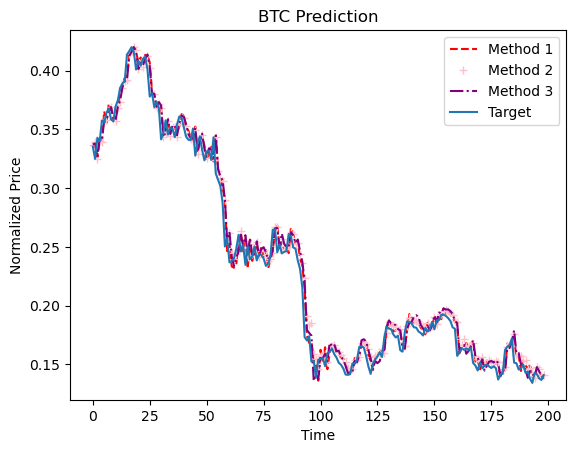

In [132]:
Ntotal = 1000
tau = 1
K = Ntotal - 1
Nfading = 100
Ntraining = 700
Ntesting = Ntotal - Nfading - Ntraining

X_features_p = X_p[0:K,:]
X_train_p = X_features_p[Nfading : Nfading + Ntraining, :]
X_test_p = X_features_p[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

X_features_p_row = X_p_row[0:K,:]
X_train_p_row = X_features_p_row[Nfading : Nfading + Ntraining, :]
X_test_p_row = X_features_p_row[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

X_features_pq = X_pq[0:K,:]
X_train_pq = X_features_pq[Nfading : Nfading + Ntraining, :]
X_test_pq = X_features_pq[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = scaled_data[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]

W_p = fitting_function(X_train_p, y_train)
y_prediction_p = predict(X_test_p, W_p)

W_p_row = fitting_function(X_train_p_row, y_train)
y_prediction_p_row = predict(X_test_p_row, W_p_row)

W_pq = fitting_function(X_train_pq, y_train)
y_prediction_pq = predict(X_test_pq, W_pq)

error = nrmse(y_prediction_p, y_test)
print("NRMSE p:", error)
error = nrmse(y_prediction_p_row, y_test)
print("NRMSE p row:", error)
error = nrmse(y_prediction_pq, y_test)
print("NRMSE pq:", error)

plt.plot(y_prediction_p[:], label='Method 1', color="Red", linestyle="--")
plt.plot(y_prediction_p_row[:], label='Method 2', color="Pink", marker="+", linestyle="")
plt.plot(y_prediction_pq[:], label='Method 3',  color="Purple", linestyle="-.")
plt.plot(y_test[:], label='Target')
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction")
plt.legend()
#plt.savefig("BTCprediction.png")

Comparing with ESN performance

In [ ]:
N = 50
A, B = make_esn_weights(
    N,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,)

X = esn_dynamics(scaled_data, A, B)

In [ ]:
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = scaled_data[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")